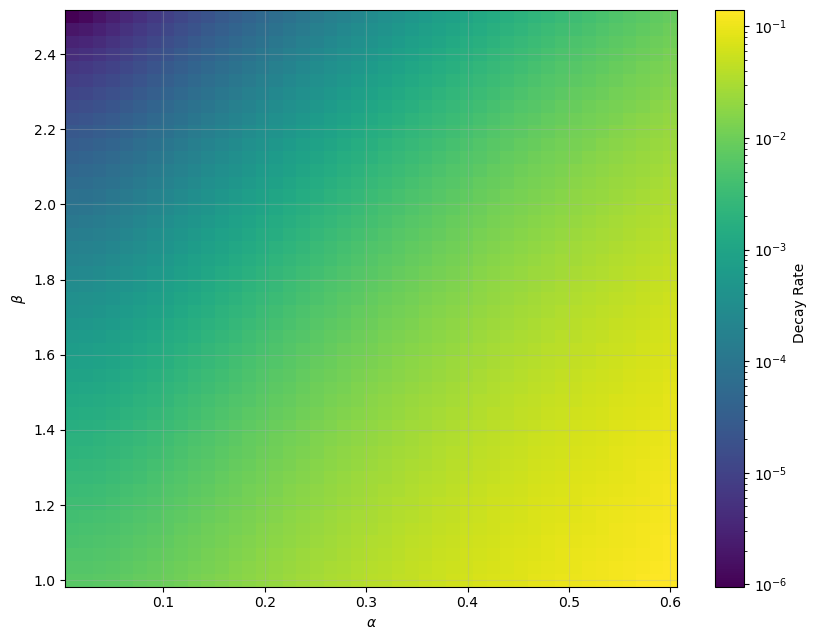

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh

# ============================================================
# GRID SETUP (same as yours)
# ============================================================

N = 4001
L = 8
phi_vals = np.linspace(-L, L, N)
dphi = phi_vals[1] - phi_vals[0]

main_diag = np.full(N, -2.0)
off_diag = np.ones(N - 1)

laplacian = diags([off_diag, main_diag, off_diag], [-1, 0, 1]) / dphi**2
T = -0.5 * laplacian


# ============================================================
# BASIC FUNCTIONS (same as yours)
# ============================================================

def Omega(alpha, beta):
    return 1 + alpha + np.sqrt(beta)

def v_shape(phi, alpha, beta):
    Om = Omega(alpha, beta)
    return (np.pi**2/(3*Om)) * (
        4*alpha*phi
        - 2*(beta/Om)*phi**2
        + (4/Om**3)*phi**4
    )

def W(phi, alpha, beta):
    Om = Omega(alpha, beta)
    v1 = (np.pi**2/(3*Om))*(
        4*alpha
        - 4*(beta/Om)*phi
        + (16/Om**3)*phi**3
    )
    v2 = (np.pi**2/(3*Om))*(
        -4*(beta/Om)
        + (48/Om**3)*phi**2
    )
    return 0.5*(v1**2 - v2)


# ============================================================
# STOCHASTIC DECAY RATE (same as yours)
# ============================================================

def Lambda1_over_H(alpha, beta, lambda_val):
    Om = Omega(alpha, beta)
    scale = np.sqrt(lambda_val) * Om**2

    W_vals = W(phi_vals, alpha, beta)
    V = diags(W_vals, 0)

    H_op = scale * (T + V)

    # Using shift-invert around 0
    E_vals, _ = eigsh(H_op, k=3, sigma=0.0, which='LM')
    E_vals = np.sort(E_vals)

    return E_vals[1] / (4*np.pi**2)


# ============================================================
# HAWKING–MOSS DECAY RATE (same as yours)
# ============================================================

def find_extrema(alpha, beta):
    Om = Omega(alpha, beta)
    p = -(beta * Om**2) / 4
    q =  (alpha * Om**3) / 4
    roots = np.roots([1, 0, p, q])
    roots = [r.real for r in roots if abs(r.imag) < 1e-10]
    return sorted(roots)

def Gamma_HM(alpha, beta):
    roots = find_extrema(alpha, beta)
    if len(roots) < 3:
        return np.nan

    Om = Omega(alpha, beta)

    def v_full(phi):
        V0 = 4*np.pi**2/(1e-3)**2
        return V0 + v_shape(phi, alpha, beta)

    def d2v(phi):
        return (np.pi**2/(3*Om))*(
            -4*beta/Om
            + 48*phi**2/Om**3
        )

    mins = [r for r in roots if d2v(r) > 0]
    maxs = [r for r in roots if d2v(r) < 0]
    if len(mins) < 2:
        return np.nan

    vmins = sorted([(x, v_full(x)) for x in mins], key=lambda t: t[1])
    phi_true, v_true = vmins[0]
    phi_false, v_false = vmins[1]

    lo, hi = sorted([phi_true, phi_false])
    candidates = [x for x in maxs if lo < x < hi]
    if len(candidates) == 0:
        return np.nan

    phi_top = candidates[0]
    Delta_v = v_full(phi_top) - v_false
    B = 2 * Delta_v
    return np.exp(-B)


# ============================================================
# 2D SCAN: alpha vs beta (heatmap)
# ============================================================

# Ranges you requested
alpha_vals = np.linspace(0.01, 0.6, 45)   # increase to refine (e.g. 80)
beta_vals  = np.linspace(1.0,  2.5, 45)   # increase to refine (e.g. 80)

# pick which decay rate you want to show
lambda_val_for_map = 0.05  # choose one of your lambdas

Z_stoch = np.full((len(beta_vals), len(alpha_vals)), np.nan)  # rows=beta, cols=alpha
Z_hm    = np.full((len(beta_vals), len(alpha_vals)), np.nan)

for i, b in enumerate(beta_vals):
    for j, a in enumerate(alpha_vals):
        # Stochastic
        try:
            Z_stoch[i, j] = Lambda1_over_H(a, b, lambda_val_for_map)
        except Exception:
            Z_stoch[i, j] = np.nan

        # Hawking–Moss (optional)
        Z_hm[i, j] = Gamma_HM(a, b)


# ============================================================
# PLOTTING
# ============================================================

# For LogNorm we need positive finite values
def positive_finite(arr):
    m = np.isfinite(arr) & (arr > 0)
    return arr[m]

vals = positive_finite(Z_stoch)
if vals.size == 0:
    raise RuntimeError("No positive finite stochastic decay-rate values to plot.")
vmin = np.nanmin(vals)
vmax = np.nanmax(vals)

A, B = np.meshgrid(alpha_vals, beta_vals)  # A: alpha grid, B: beta grid

fig, ax = plt.subplots(figsize=(8.5, 6.5))

im = ax.pcolormesh(
    A, B, Z_stoch,
    shading="auto",
    norm=LogNorm(vmin=vmin, vmax=vmax)
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"Decay Rate  ")

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\beta$")
#ax.set_title(rf"Decay-rate map: $\Lambda_1/H$ over $(\alpha,\beta)$  (fixed $\lambda={lambda_val_for_map}$)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("Heatmap", dpi=300, bbox_inches="tight")
plt.show()




In [14]:
import os
print(os.getcwd())


/net/theorie/home/ata.aziziseraji


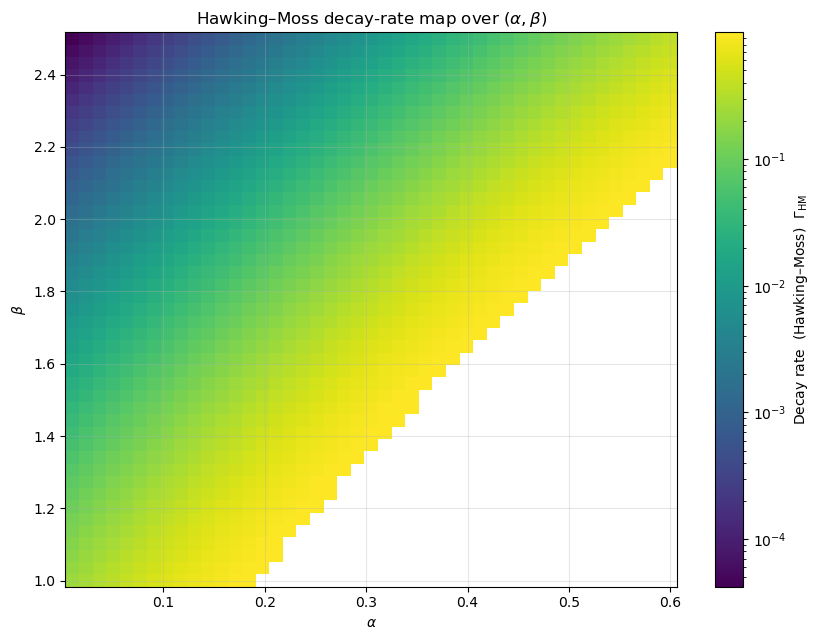

In [10]:
# ============================================================
# OPTIONAL: also show Hawking–Moss map in a second figure
# ============================================================

vals_hm = positive_finite(Z_hm)
if vals_hm.size > 0:
    vmin_hm = np.nanmin(vals_hm)
    vmax_hm = np.nanmax(vals_hm)

    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    im = ax.pcolormesh(
        A, B, Z_hm,
        shading="auto",
        norm=LogNorm(vmin=vmin_hm, vmax=vmax_hm)
    )
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"Decay rate  (Hawking–Moss)  $\Gamma_{\rm HM}$")

    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"$\beta$")
    ax.set_title(r"Hawking–Moss decay-rate map over $(\alpha,\beta)$")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("HM map has no positive finite values in this range (all nan/<=0).")